# Load Traced Artifacts and Predict


This notebook reads the persisted configs from the Torch example, reloads the saved splits and trained model checkpoint from `data/torch_classification/`, and makes a tiny prediction.

In [1]:
# need the project root to be in the path for imports to work
import sys
import os
current_path = os.getcwd()
# it's the parent directory of the current working dir
project_root = os.path.dirname(current_path)
sys.path.append(project_root)

from collections import defaultdict
from pathlib import Path
from pprint import pprint

import torch

from research_pipelines.backends.pickle_backend import PickleBackend
from research_pipelines.backends.manager import set_backend
import research_pipelines.dag as dag

we can also integrate with wandb, but the basic pickle logging needs an explicit path

In [2]:
project_root = Path.cwd()
if not (project_root / 'data').exists() and (project_root.parent / 'data').exists():
    project_root = project_root.parent

artifact_root = project_root / 'data' / 'torch_classification'
# automatic for wandb, but pickle needs a path
backend = PickleBackend(directory=str(artifact_root / 'traced_configs'))
backend.set_recording_enabled(False) 
set_backend(backend)
configs = backend.load_all()

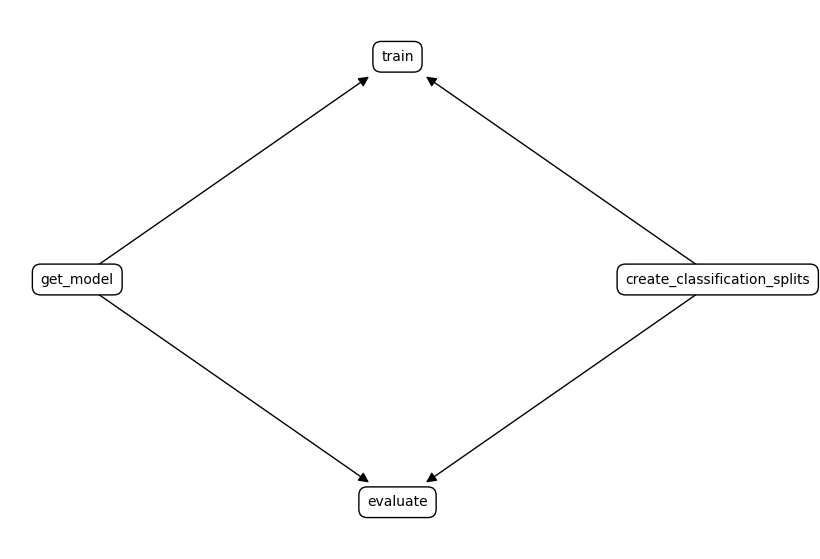

In [3]:
import research_pipelines.visualize as viz
viz.visualize_dag(backend)

### We can build the dataset-object again

In [4]:
import importlib
import research_pipelines.query as query
importlib.reload(query)

<module 'research_pipelines.query' from '/Users/leanderkurscheidt/Projects/research_pipelines/src/research_pipelines/query.py'>

In [5]:
from examples.simple_pipeline import create_classification_splits, evaluate

# the path got ignored and not persisted, so we need to provide it manually here
# as it is relative, in a notebook it would point to the wrong location
manual_args = {'artifact_root': str(artifact_root)}

# we can now easily recreate the data-splits!
train_split, val_split, test_split = query.build(
    create_classification_splits,
    manual_args,

)

#### Or just get the arguments needed to evaluate the model

In [7]:
# or just get the arguments for a traced function and call it ourselves
args = query.build_arguments(
    evaluate,
    manual_args,
)
# we can pattern match on it or get the kwargs via args.to_kwargs()
(model, test_split, artifact_root) = args

checkpoint = project_root / 'data/torch_classification/checkpoints/simple_classifier.pt'
state_dict = torch.load(checkpoint)
model.load_state_dict(state_dict['state_dict'])

evaluate(model, test_split, artifact_root)

{'test_accuracy': 1.0, 'num_examples': 24}